# 11: LOGO explainability

Compared explanations for GLIDE, Wukong, and Midjourney, representing the best, middle, and worst baseline CNN LOGO results. Neural checkpoints are reused without retraining. Frequency models will be refitted in a later section.


## 1. Setup and artifact validation


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'configs' / 'experiments.yaml').is_file():
            return candidate
    raise FileNotFoundError('Could not find the repository root.')

REPO_ROOT = find_repo_root(Path.cwd().resolve())
sys.path.insert(0, str(REPO_ROOT))
from src.data.config import load_config
from src.training import set_seed

config = load_config()
SEED = config['seed']
set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PROCESSED_ROOT = REPO_ROOT / 'data' / 'processed'
FIGURES_ROOT = REPO_ROOT / 'results' / 'figures' / 'logo_explainability'
METRICS_ROOT = REPO_ROOT / 'results' / 'metrics' / 'logo_explainability'
FIGURES_ROOT.mkdir(parents=True, exist_ok=True)
METRICS_ROOT.mkdir(parents=True, exist_ok=True)
GENERATORS = ['glide', 'wukong', 'midjourney']
MODEL_NAMES = ['baseline_cnn', 'resnet18', 'vit_small', 'frequency_radial', 'frequency_hybrid']

artifact_rows = []
for generator in GENERATORS:
    checkpoint_root = REPO_ROOT / 'results' / 'checkpoints' / f'logo_{generator}'
    for model_name, filename in {'baseline_cnn':'baseline_cnn.pt','resnet18':'resnet18.pt','vit_small':'vit_small.pt'}.items():
        path = checkpoint_root / filename
        artifact_rows.append({'generator':generator,'model':model_name,'available':path.is_file(),'path':path.relative_to(REPO_ROOT).as_posix()})
display(pd.DataFrame(artifact_rows))
assert all(row['available'] for row in artifact_rows), 'One or more neural checkpoints are missing.'
print(f'Device: {device}')


,generator,model,available,path
0,glide,baseline_cnn,True,results/checkpoints/logo_glide/baseline_cnn.pt
1,glide,resnet18,True,results/checkpoints/logo_glide/resnet18.pt
2,glide,vit_small,True,results/checkpoints/logo_glide/vit_small.pt
3,wukong,baseline_cnn,True,results/checkpoints/logo_wukong/baseline_cnn.pt
4,wukong,resnet18,True,results/checkpoints/logo_wukong/resnet18.pt
5,wukong,vit_small,True,results/checkpoints/logo_wukong/vit_small.pt
6,midjourney,baseline_cnn,True,results/checkpoints/logo_midjourney/baseline_c...
7,midjourney,resnet18,True,results/checkpoints/logo_midjourney/resnet18.pt
8,midjourney,vit_small,True,results/checkpoints/logo_midjourney/vit_small.pt


Device: cpu


## 2. Load and compare existing LOGO predictions

All models are compared on the same held out generator images. These CSV files contain final predictions, so this step does not load or run any model.


In [2]:
logo_predictions = {}
for generator in GENERATORS:
    merged = None
    for model_name in MODEL_NAMES:
        path = REPO_ROOT / 'results' / 'metrics' / f'logo_{generator}' / model_name / 'test_predictions.csv'
        assert path.is_file(), f'Missing predictions: {path.relative_to(REPO_ROOT)}'
        frame = pd.read_csv(path)[['filename','label','generator','probability_ai','prediction']].rename(columns={'probability_ai':f'{model_name}_p_ai','prediction':f'{model_name}_pred'})
        merged = frame if merged is None else merged.merge(frame.drop(columns=['label','generator']), on='filename', validate='one_to_one')
    for model_name in MODEL_NAMES:
        merged[f'{model_name}_correct'] = merged[f'{model_name}_pred'] == merged['label']
    merged['correct_count'] = merged[[f'{name}_correct' for name in MODEL_NAMES]].sum(axis=1)
    merged['probability_range'] = merged[[f'{name}_p_ai' for name in MODEL_NAMES]].max(axis=1) - merged[[f'{name}_p_ai' for name in MODEL_NAMES]].min(axis=1)
    logo_predictions[generator] = merged
    print(generator, 'images:', len(merged), 'all correct:', int((merged.correct_count == 5).sum()), 'all wrong:', int((merged.correct_count == 0).sum()))


glide images: 2050 all correct: 1018 all wrong: 13
wukong images: 2050 all correct: 676 all wrong: 143
midjourney images: 2050 all correct: 659 all wrong: 243


## 3. Select shared qualitative examples

For each held out generator, select examples representing full agreement, systematic failure, neural and frequency disagreement, and the largest probability disagreement. The categories are neutral and do not describe only one model.


,case_type,filename,label,baseline_cnn_p_ai,resnet18_p_ai,vit_small_p_ai,frequency_radial_p_ai,frequency_hybrid_p_ai
0,all_correct,ai/glide__GLIDE_1000_200_08_803_glide_00074.jpg,ai,0.508284,0.517495,0.821570,5.091964e-01,0.700818
1,all_wrong,real/adm__ILSVRC2012_val_00042917.jpg,real,0.612221,0.888482,0.917742,5.457942e-01,0.660407
2,neural_disagreement,real/glide__ILSVRC2012_val_00000943.jpg,real,0.571139,0.817707,0.073338,4.762630e-01,0.443677
3,frequency_disagreement,real/adm__ILSVRC2012_val_00044467.jpg,real,0.697253,0.393706,0.000217,5.245494e-01,0.460340
4,largest_probability_disagreement,real/sdv1_5__ILSVRC2012_val_00047245.jpg,real,0.970766,0.522878,0.962992,7.578909e-08,0.000176
5,largest_probability_disagreement,real/midjourney__ILSVRC2012_val_00019663.jpg,real,0.038972,0.961102,0.003650,4.946516e-01,0.389512


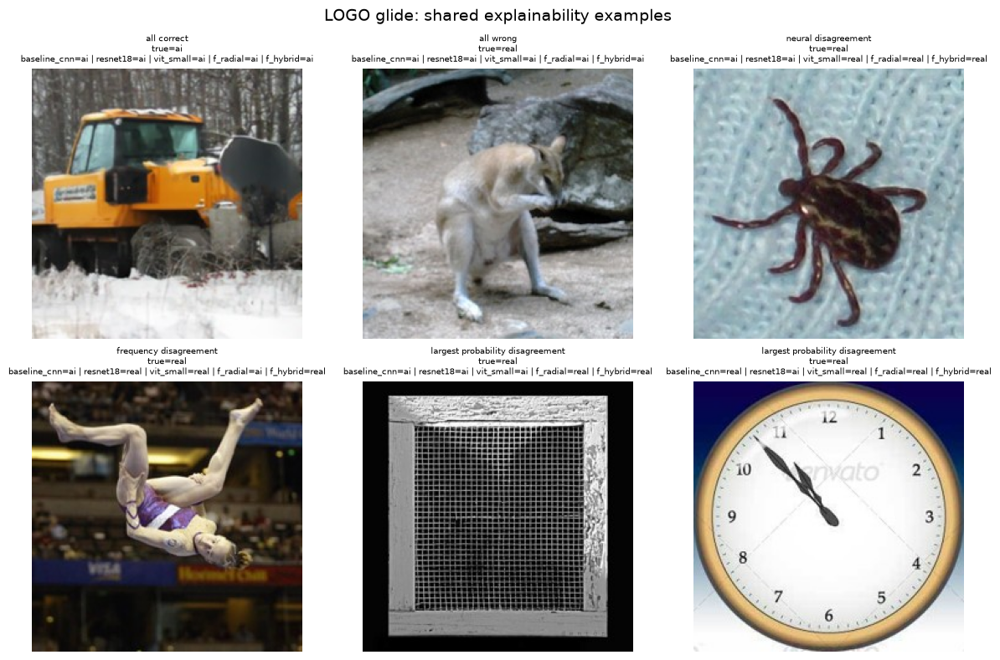

Saved: results\figures\logo_explainability\logo_glide_shared_examples.png


,case_type,filename,label,baseline_cnn_p_ai,resnet18_p_ai,vit_small_p_ai,frequency_radial_p_ai,frequency_hybrid_p_ai
0,all_correct,real/wukong__ILSVRC2012_val_00041616.jpg,real,0.206990,0.013747,0.001569,0.476841,0.252711
1,all_wrong,ai/wukong__983_wukong_image176.jpg,ai,0.145397,0.035660,0.040531,0.438969,0.290486
2,neural_disagreement,real/adm__ILSVRC2012_val_00029991.jpg,real,0.704130,0.161458,0.808027,0.535034,0.552229
3,frequency_disagreement,ai/wukong__643_wukong_image41.jpg,ai,0.470507,0.951985,0.992841,0.559499,0.397337
4,largest_probability_disagreement,ai/wukong__890_wukong_image85.jpg,ai,0.011458,0.871007,0.998774,0.267641,0.534750
5,largest_probability_disagreement,ai/wukong__594_wukong_image199.jpg,ai,0.179418,0.310644,0.988546,0.004525,0.375784


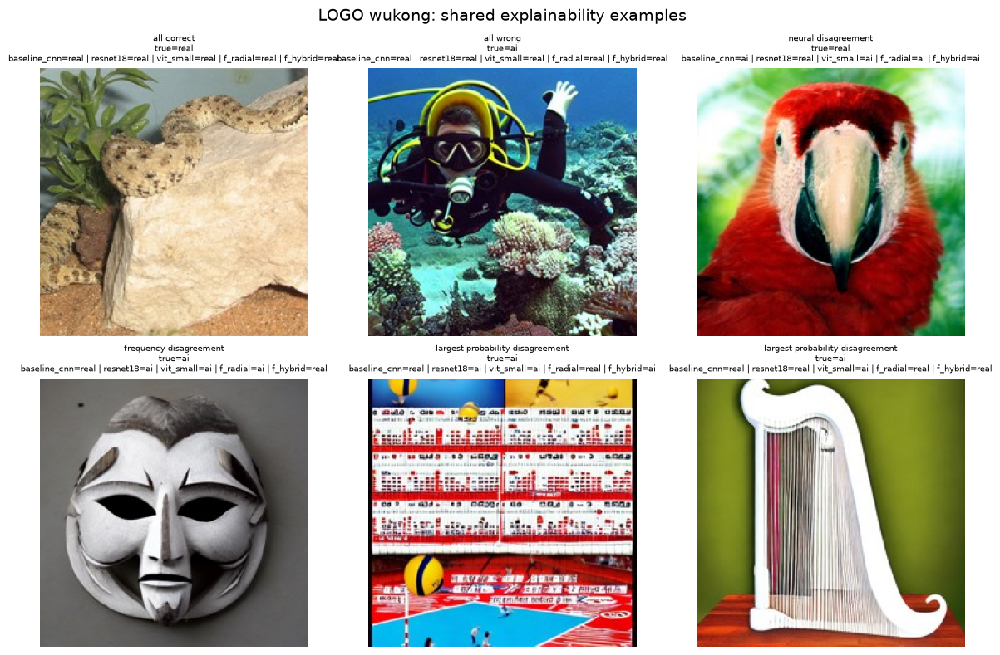

Saved: results\figures\logo_explainability\logo_wukong_shared_examples.png


,case_type,filename,label,baseline_cnn_p_ai,resnet18_p_ai,vit_small_p_ai,frequency_radial_p_ai,frequency_hybrid_p_ai
0,all_correct,real/wukong__ILSVRC2012_val_00022467.jpg,real,0.100600,0.004082,0.000303,0.494600,0.185392
1,all_wrong,ai/midjourney__900_midjourney_71.jpg,ai,0.031973,0.160823,0.008567,0.355625,0.121878
2,neural_disagreement,real/adm__ILSVRC2012_val_00028600.jpg,real,0.146388,0.564626,0.062517,0.456151,0.308262
3,frequency_disagreement,ai/midjourney__909_midjourney_197.jpg,ai,0.278132,0.911420,0.983041,0.546319,0.373150
4,largest_probability_disagreement,ai/midjourney__976_midjourney_77.jpg,ai,0.020604,0.003902,0.995597,0.368683,0.300972
5,largest_probability_disagreement,ai/midjourney__381_midjourney_103.jpg,ai,0.019966,0.491991,0.997049,0.434789,0.200738


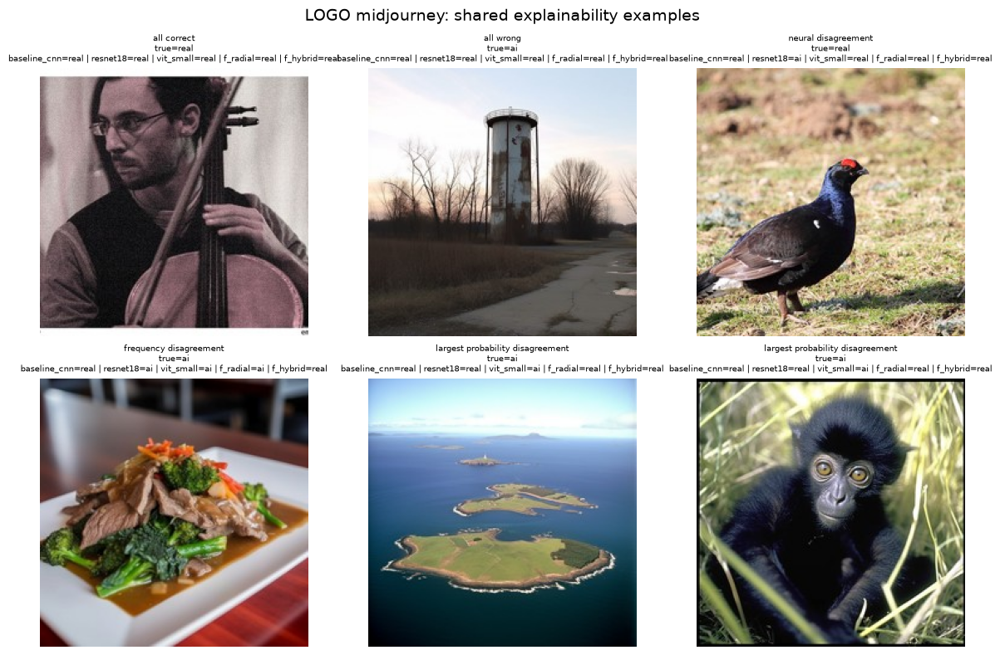

Saved: results\figures\logo_explainability\logo_midjourney_shared_examples.png


In [3]:
selected_logo_examples = {}
for generator, table in logo_predictions.items():
    masks = {'all_correct':table.correct_count == 5,'all_wrong':table.correct_count == 0,'neural_disagreement':table[[f'{n}_correct' for n in ['baseline_cnn','resnet18','vit_small']]].nunique(axis=1) > 1,'frequency_disagreement':table.frequency_radial_correct != table.frequency_hybrid_correct}
    parts=[]; used=set()
    for offset,(case,mask) in enumerate(masks.items()):
        pool=table[mask & ~table.filename.isin(used)]
        if len(pool):
            chosen=pool.sample(n=1,random_state=SEED+offset).assign(case_type=case); parts.append(chosen); used.update(chosen.filename)
    extra=table[~table.filename.isin(used)].nlargest(2,'probability_range').assign(case_type='largest_probability_disagreement')
    parts.append(extra)
    selected=pd.concat(parts,ignore_index=True)
    selected_logo_examples[generator]=selected
    display(selected[['case_type','filename','label']+[f'{n}_p_ai' for n in MODEL_NAMES]])
    fig,axes=plt.subplots(2,3,figsize=(12,8)); [ax.axis('off') for ax in axes.flat]
    for ax,(_,row) in zip(axes.flat,selected.iterrows()):
        with Image.open(PROCESSED_ROOT/row.filename) as image: ax.imshow(image.convert('RGB'))
        summary=' | '.join(f"{n.replace('frequency_','f_')}={row[f'{n}_pred']}" for n in MODEL_NAMES)
        ax.set_title(f"{row.case_type.replace('_',' ')}\ntrue={row.label}\n{summary}",fontsize=7); ax.axis('off')
    fig.suptitle(f'LOGO {generator}: shared explainability examples',fontsize=14); fig.tight_layout()
    path=FIGURES_ROOT/f'logo_{generator}_shared_examples.png'; fig.savefig(path,dpi=150,bbox_inches='tight'); plt.show(); print(f'Saved: {path.relative_to(REPO_ROOT)}')


## 4. Neural model explanations

Compare baseline CNN Grad CAM, ResNet18 Grad CAM, and ViT attention rollout on the same shared examples. ViT rollout is not class specific, and colour intensity is not directly comparable between methods.


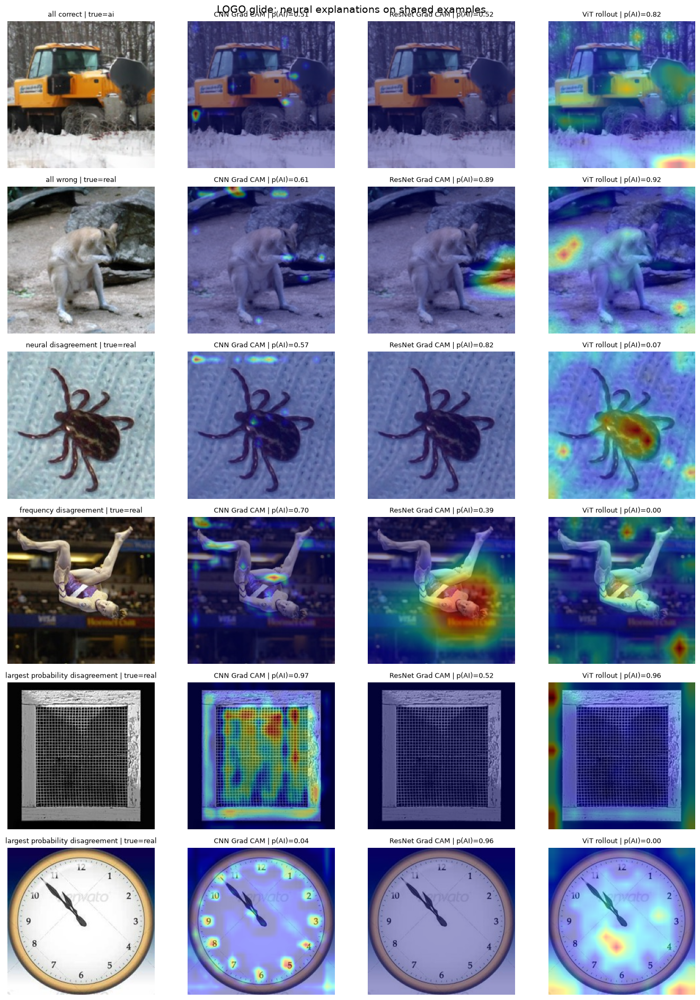

Saved: results\figures\logo_explainability\logo_glide_neural_explanations.png


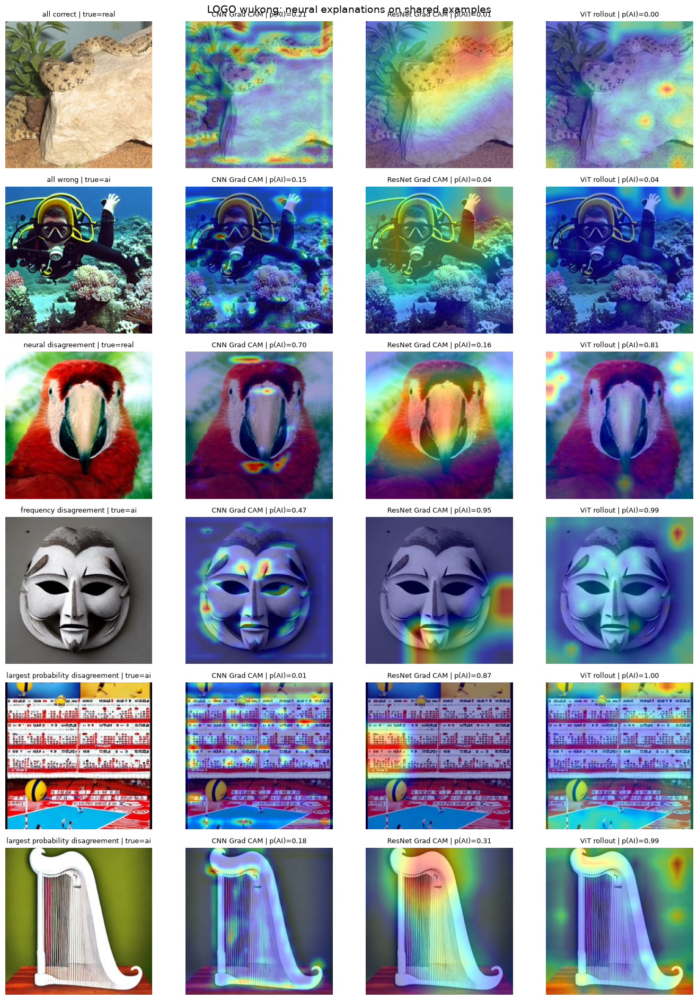

Saved: results\figures\logo_explainability\logo_wukong_neural_explanations.png


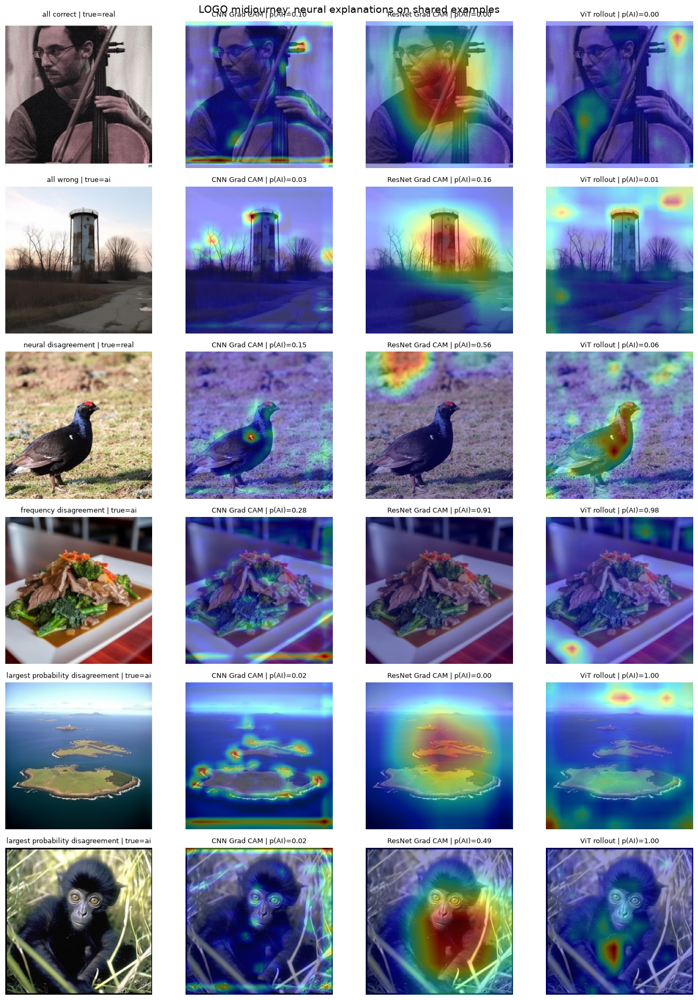

Saved: results\figures\logo_explainability\logo_midjourney_neural_explanations.png


In [4]:
import gc
import timm
from torchvision.models import resnet18
from src.data.loaders import build_image_transform, build_pretrained_transform, build_vit_transform
from src.evaluation.explainability import attention_rollout, gradcam, resize_map
from src.models import BaselineCNN
from src.models.heads import BinaryHead

cnn_transform = build_image_transform()
resnet_transform = build_pretrained_transform()
vit_transform = build_vit_transform(config['vit']['model_name'])

for generator in GENERATORS:
    checkpoint_root = REPO_ROOT / 'results' / 'checkpoints' / f'logo_{generator}'

    cnn_filename = 'baseline_cnn_mine.pt' if generator == 'wukong' else 'baseline_cnn.pt'
    cnn_checkpoint = torch.load(checkpoint_root / cnn_filename, map_location=device, weights_only=True)
    cnn = BaselineCNN(channels=tuple(config['baseline_cnn']['channels']), dropout=config['baseline_cnn']['dropout']).to(device)
    cnn.load_state_dict(cnn_checkpoint['model_state_dict'])
    cnn.eval()

    resnet_checkpoint = torch.load(checkpoint_root / 'resnet18.pt', map_location=device, weights_only=True)
    resnet = resnet18(weights=None)
    resnet.fc = BinaryHead(resnet.fc.in_features, dropout=config['resnet']['head_dropout'])
    resnet.load_state_dict(resnet_checkpoint['model_state_dict'])
    resnet = resnet.to(device).eval()

    vit_checkpoint = torch.load(checkpoint_root / 'vit_small.pt', map_location=device, weights_only=True)
    vit = timm.create_model(config['vit']['model_name'], pretrained=False, num_classes=1, drop_path_rate=config['vit']['drop_path_rate'])
    vit.head = BinaryHead(vit.head.in_features)
    vit.load_state_dict(vit_checkpoint['model_state_dict'])
    vit = vit.to(device).eval()

    examples = selected_logo_examples[generator]
    fig, axes = plt.subplots(len(examples), 4, figsize=(14, 3.2 * len(examples)))
    for row_axes, (_, row) in zip(axes, examples.iterrows()):
        with Image.open(PROCESSED_ROOT / row.filename) as image:
            rgb = image.convert('RGB')
            image_array = np.asarray(rgb)
            cnn_input = cnn_transform(rgb).unsqueeze(0).to(device)
            resnet_input = resnet_transform(rgb).unsqueeze(0).to(device)
            vit_input = vit_transform(rgb).unsqueeze(0).to(device)
        cnn_map, cnn_probability = gradcam(cnn, cnn.features[-1][0], cnn_input, row.baseline_cnn_pred)
        resnet_map, resnet_probability = gradcam(resnet, resnet.layer4[-1].conv2, resnet_input, row.resnet18_pred)
        vit_map, vit_probability = attention_rollout(vit, vit_input)
        assert np.isclose(cnn_probability, row.baseline_cnn_p_ai, atol=1e-5)
        assert np.isclose(resnet_probability, row.resnet18_p_ai, atol=1e-5)
        assert np.isclose(vit_probability, row.vit_small_p_ai, atol=1e-5)
        maps = [resize_map(cnn_map, image_array.shape[:2]), resize_map(resnet_map, image_array.shape[:2]), resize_map(vit_map, image_array.shape[:2])]
        row_axes[0].imshow(image_array)
        row_axes[0].set_title(f"{row.case_type.replace('_', ' ')} | true={row.label}", fontsize=9)
        titles = [f'CNN Grad CAM | p(AI)={cnn_probability:.2f}', f'ResNet Grad CAM | p(AI)={resnet_probability:.2f}', f'ViT rollout | p(AI)={vit_probability:.2f}']
        for ax, values, title in zip(row_axes[1:], maps, titles):
            ax.imshow(image_array)
            ax.imshow(values, cmap='jet', alpha=0.4, vmin=0, vmax=1)
            ax.set_title(title, fontsize=9)
        for ax in row_axes:
            ax.axis('off')
    fig.suptitle(f'LOGO {generator}: neural explanations on shared examples', fontsize=14)
    fig.tight_layout()
    output_path = FIGURES_ROOT / f'logo_{generator}_neural_explanations.png'
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {output_path.relative_to(REPO_ROOT)}')
    del cnn, resnet, vit, cnn_checkpoint, resnet_checkpoint, vit_checkpoint
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()


## 5. Frequency explanations

Load the fitted radial and hybrid Logistic Regression pipelines for all three LOGO folds. Compare their global coefficients and calculate local additive contributions for the same shared examples. Red contributions increase the AI logit and blue contributions decrease it.


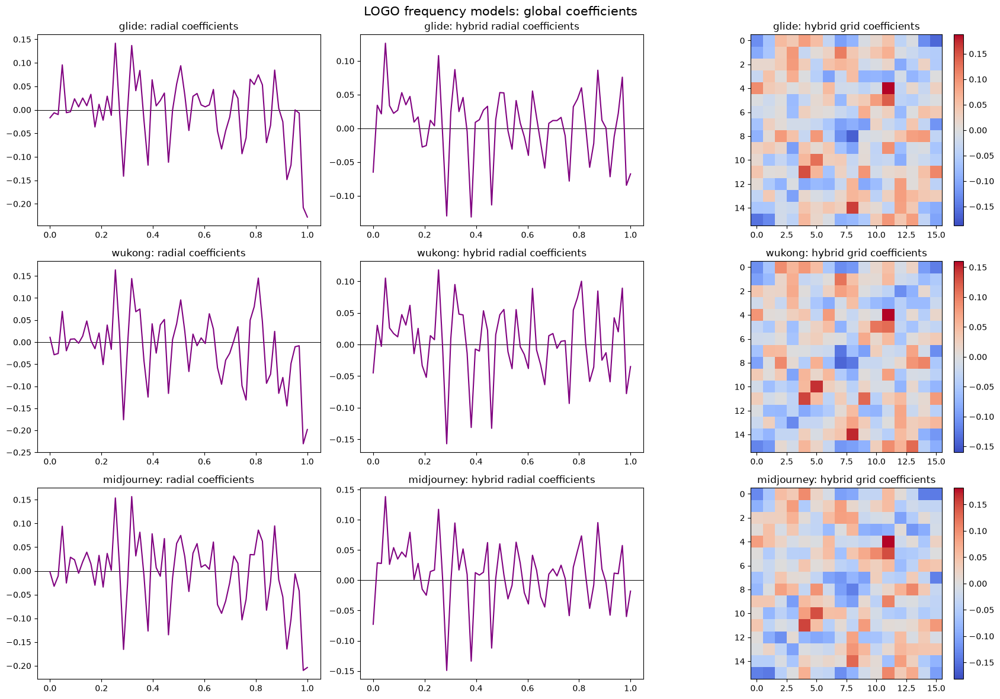

Saved: results\figures\logo_explainability\logo_frequency_global_coefficients.png


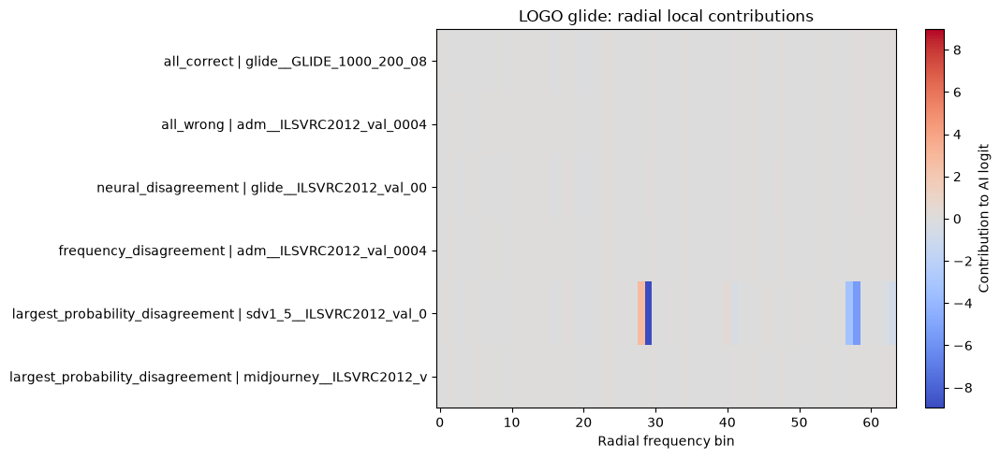

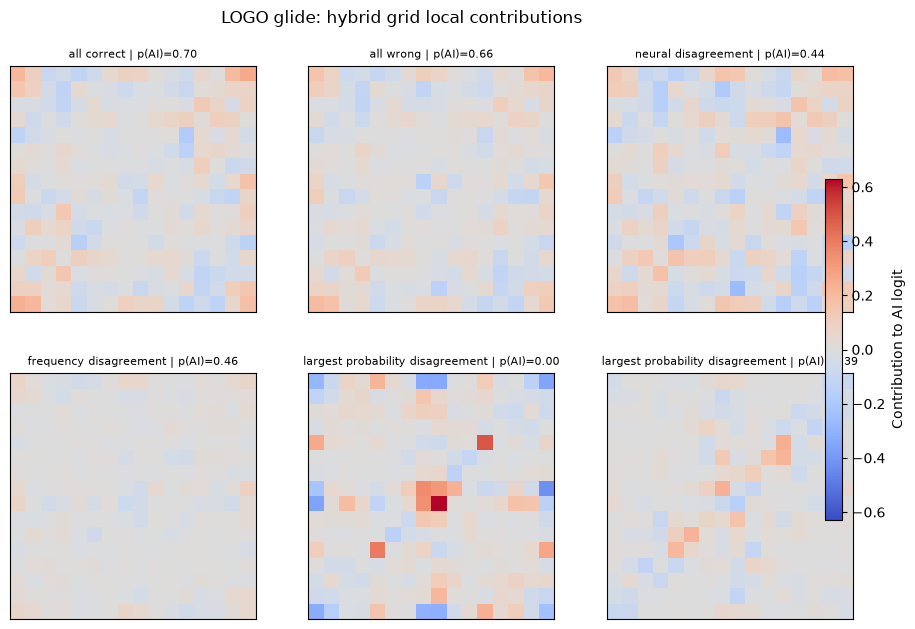

Saved frequency explanations for glide


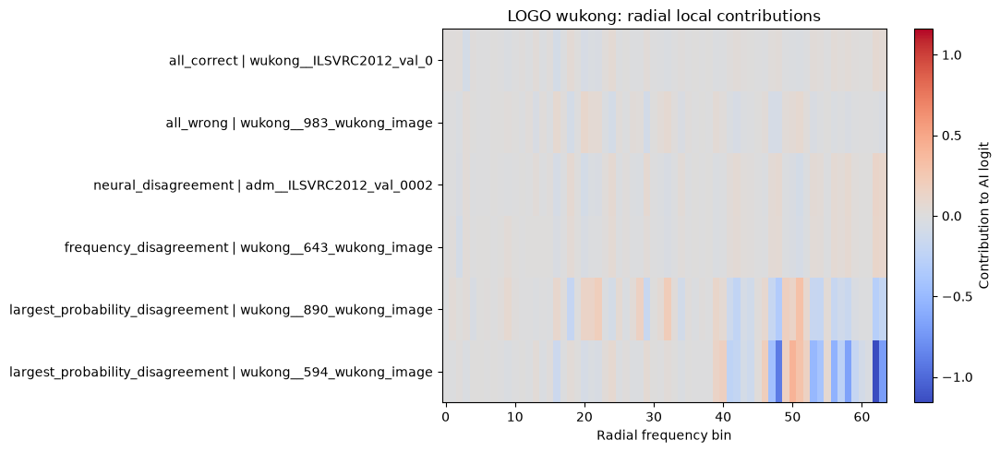

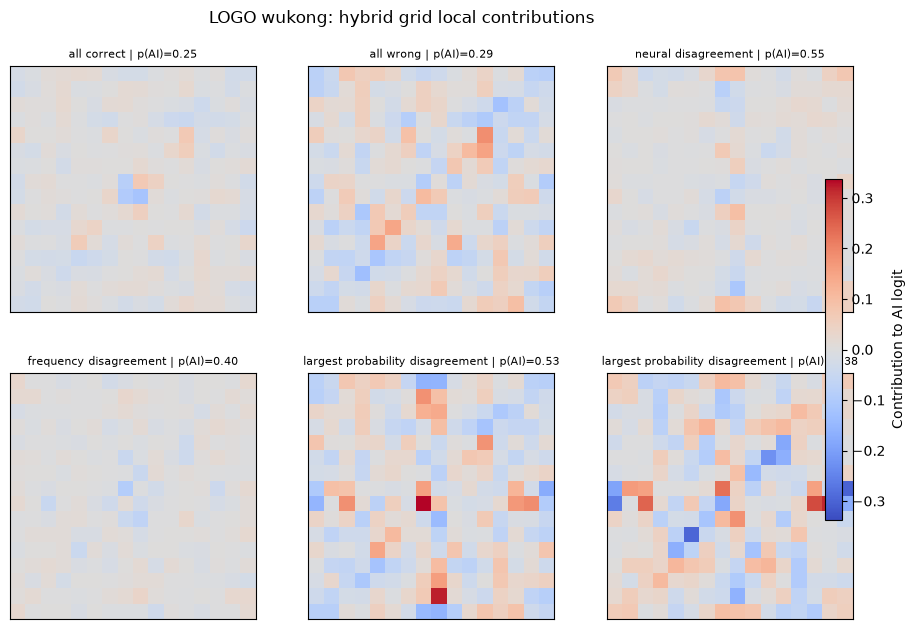

Saved frequency explanations for wukong


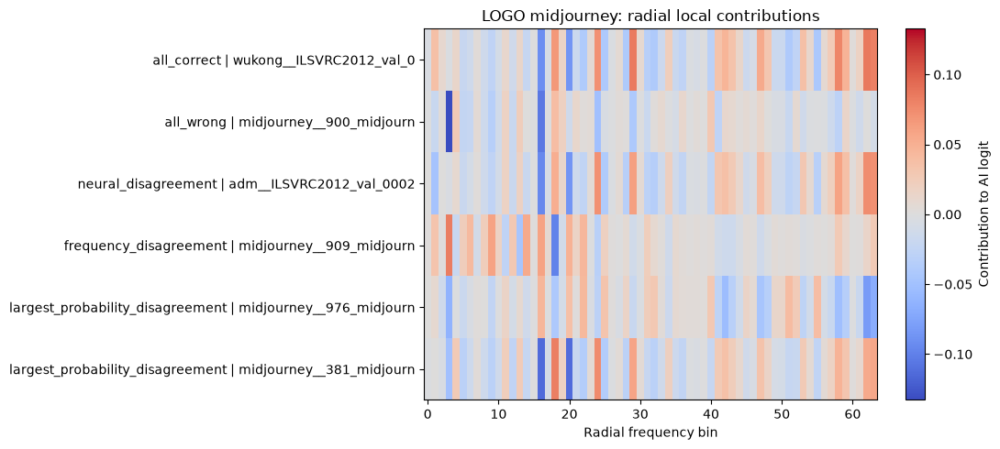

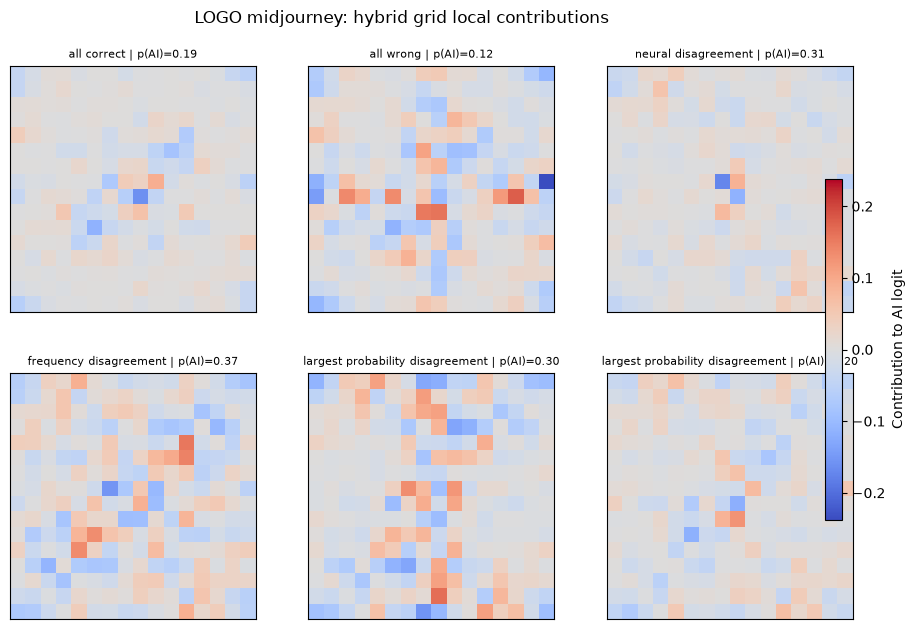

Saved frequency explanations for midjourney


In [5]:
import joblib
from matplotlib.colors import TwoSlopeNorm
from src.features import compute_log_power_grid, compute_normalized_power_spectrum, compute_radial_energy_profile, image_to_luminance

RADIAL_BINS, GRID_SIZE = 64, 16
def extract_frequency(filename):
    with Image.open(PROCESSED_ROOT / filename) as image:
        power = compute_normalized_power_spectrum(image_to_luminance(image))
    radial = compute_radial_energy_profile(power, bins=RADIAL_BINS)
    return radial, np.concatenate((radial, compute_log_power_grid(power, grid_size=GRID_SIZE).ravel()))

frequency_models = {}
fig, axes = plt.subplots(len(GENERATORS), 3, figsize=(17, 12))
for row_index, generator in enumerate(GENERATORS):
    root = REPO_ROOT / 'results' / 'models' / f'logo_{generator}'
    radial_model = joblib.load(root / 'frequency_radial.joblib')
    hybrid_model = joblib.load(root / 'frequency_hybrid.joblib')
    frequency_models[generator] = {'radial': radial_model, 'hybrid': hybrid_model}
    radial_coef = radial_model.named_steps['classifier'].coef_[0]
    hybrid_coef = hybrid_model.named_steps['classifier'].coef_[0]
    axes[row_index,0].axhline(0,color='black',linewidth=.7); axes[row_index,0].plot(np.linspace(0,1,RADIAL_BINS),radial_coef,color='purple'); axes[row_index,0].set_title(f'{generator}: radial coefficients')
    axes[row_index,1].axhline(0,color='black',linewidth=.7); axes[row_index,1].plot(np.linspace(0,1,RADIAL_BINS),hybrid_coef[:RADIAL_BINS],color='purple'); axes[row_index,1].set_title(f'{generator}: hybrid radial coefficients')
    grid = hybrid_coef[RADIAL_BINS:].reshape(GRID_SIZE,GRID_SIZE); limit=np.abs(grid).max()
    image=axes[row_index,2].imshow(grid,cmap='coolwarm',norm=TwoSlopeNorm(vmin=-limit,vcenter=0,vmax=limit)); axes[row_index,2].set_title(f'{generator}: hybrid grid coefficients'); fig.colorbar(image,ax=axes[row_index,2],fraction=.046,pad=.04)
fig.suptitle('LOGO frequency models: global coefficients',fontsize=15); fig.tight_layout()
global_path=FIGURES_ROOT/'logo_frequency_global_coefficients.png'; fig.savefig(global_path,dpi=150,bbox_inches='tight'); plt.show(); print(f'Saved: {global_path.relative_to(REPO_ROOT)}')

for generator in GENERATORS:
    examples=selected_logo_examples[generator]
    radial_features=[]; hybrid_features=[]
    for filename in examples.filename:
        radial,hybrid=extract_frequency(filename); radial_features.append(radial); hybrid_features.append(hybrid)
    radial_features=np.stack(radial_features); hybrid_features=np.stack(hybrid_features)
    radial_model=frequency_models[generator]['radial']; hybrid_model=frequency_models[generator]['hybrid']
    radial_p=radial_model.predict_proba(radial_features)[:,1]; hybrid_p=hybrid_model.predict_proba(hybrid_features)[:,1]
    assert np.allclose(radial_p,examples.frequency_radial_p_ai,atol=1e-5) and np.allclose(hybrid_p,examples.frequency_hybrid_p_ai,atol=1e-5)
    radial_local=radial_model.named_steps['scaler'].transform(radial_features)*radial_model.named_steps['classifier'].coef_[0]
    hybrid_local=hybrid_model.named_steps['scaler'].transform(hybrid_features)*hybrid_model.named_steps['classifier'].coef_[0]
    labels=[f"{r.case_type} | {Path(r.filename).stem[:24]}" for r in examples.itertuples()]
    limit=np.abs(radial_local).max(); fig,ax=plt.subplots(figsize=(11,5)); image=ax.imshow(radial_local,aspect='auto',cmap='coolwarm',vmin=-limit,vmax=limit); ax.set(title=f'LOGO {generator}: radial local contributions',xlabel='Radial frequency bin',yticks=range(len(labels)),yticklabels=labels); fig.colorbar(image,ax=ax,label='Contribution to AI logit'); fig.tight_layout(); path=FIGURES_ROOT/f'logo_{generator}_radial_contributions.png'; fig.savefig(path,dpi=150,bbox_inches='tight'); plt.show()
    grids=hybrid_local[:,RADIAL_BINS:].reshape(-1,GRID_SIZE,GRID_SIZE); limit=np.abs(grids).max(); fig,axes=plt.subplots(2,3,figsize=(11,7))
    for ax,grid,(_,r) in zip(axes.flat,grids,examples.iterrows()): image=ax.imshow(grid,cmap='coolwarm',vmin=-limit,vmax=limit); ax.set_title(f"{r.case_type.replace('_',' ')} | p(AI)={r.frequency_hybrid_p_ai:.2f}",fontsize=8); ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(image,ax=axes,fraction=.02,pad=.02,label='Contribution to AI logit'); fig.suptitle(f'LOGO {generator}: hybrid grid local contributions'); fig.subplots_adjust(top=.90,right=.91,wspace=.12,hspace=.25); path=FIGURES_ROOT/f'logo_{generator}_hybrid_grid_contributions.png'; fig.savefig(path,dpi=150,bbox_inches='tight'); plt.show(); print(f'Saved frequency explanations for {generator}')


## 6. Discussion

The three folds form a clear progression in baseline CNN generalization. GLIDE is the easiest held out generator, Wukong is intermediate, and Midjourney is the hardest. The number of images misclassified by every evaluated model rises from 13 for GLIDE to 143 for Wukong and 243 for Midjourney. This indicates that the difficulty is shared across representations rather than being restricted to one architecture.

CNN Grad CAM frequently emphasizes local texture, edges, and small high contrast regions. ResNet18 often covers larger parts of the principal object, although some maps are weak or focus on context. ViT attention rollout frequently differs strongly from both convolutional models and can recognize Wukong or Midjourney images that they classify as real. Attention rollout is not class specific, so it describes information flow rather than direct evidence for a label.

Frequency generalization also depends on the generator. For GLIDE, the hybrid model achieves F1 0.9031 and ROC AUC 0.9670, substantially outperforming the radial model. For Wukong and Midjourney, hybrid F1 falls to 0.3670 and 0.3836. The additional two dimensional grid is therefore highly informative for GLIDE artifacts but does not provide a generator independent solution.

The radial and hybrid classifiers can disagree even though they share the same radial features. Hybrid predictions additionally depend on directional structure in the coarse frequency grid. Local contribution plots explain how standardized features combine with learned coefficients, but correlated spectral features prevent a causal interpretation of any single coefficient.

Overall, no explanation pattern remains stable across all unseen generators. Spatial models can attend to plausible objects and still predict real for generated images, while frequency models can confidently reject AI images whose spectra differ from artifacts learned during training. The results support reporting performance separately for each unseen generator and combining quantitative metrics with shared example analysis. Grad CAM, attention rollout, and frequency contributions remain diagnostic tools rather than proof of causal model reasoning.
